In [2]:
import os
[print(f) for f in os.listdir()]


comaprison.ipynb
federated_IID_new.ipynb
best_fedprox_moderate_pretrained_alpha3.pth
best_fedprox_iid_pretrained.pth
metrics_history_fedavg_iid_pretrained.npy
best_fedavg_extreme_pretrained_NEW.pth
fedprox_extreme_pretrained_confusion_matrix.npy
metrics_history_fedavg_moderate_pretrained_alpha3.npy
best_fedavg_moderate_pretrained_alpha3.pth
metrics_history_fedprox_moderate_pretrained_alpha3.npy
fedavg_extreme_pretrained_NEW_confusion_matrix.npy
federated_moderate_noniid_new copy.ipynb
fedavg_iid_pretrained_loss.npy
best_fedavg_extreme_pretrained.pth
fedavg_iid_pretrained_rounds.npy
fedavg_moderate_alpha3_confusion_matrix.npy
fedprox_iid_pretrained_loss.npy
fedprox_iid_pretrained_confusion_matrix.npy
metrics_history_fedavg_extreme_pretrained.npy
metrics_history_fedprox_extreme_pretrained.npy
fedavg_iid_pretrained_confusion_matrix.npy
federated_extreme_iid_new.ipynb
metrics_history_fedprox_iid_pretrained.npy
best_fedavg_iid_pretrained.pth
best_fedprox_extreme_pretrained.pth
metrics_histo

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

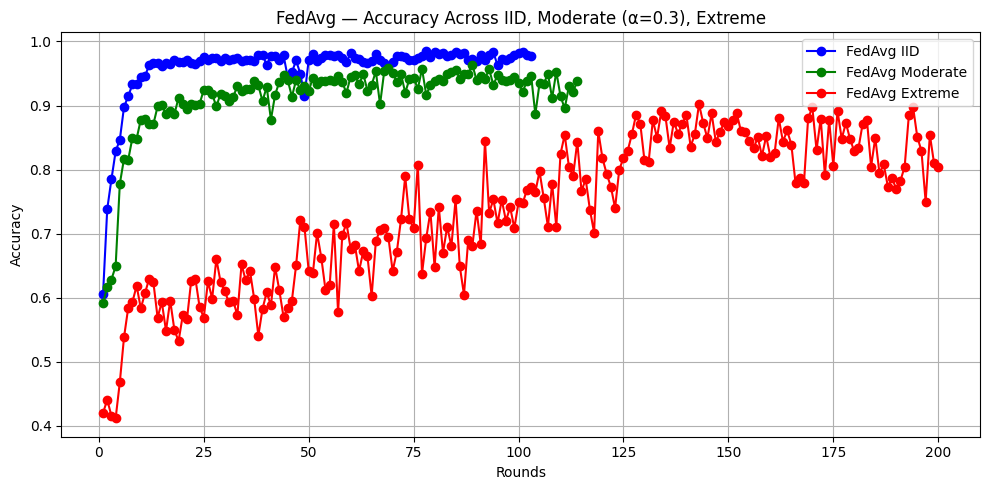

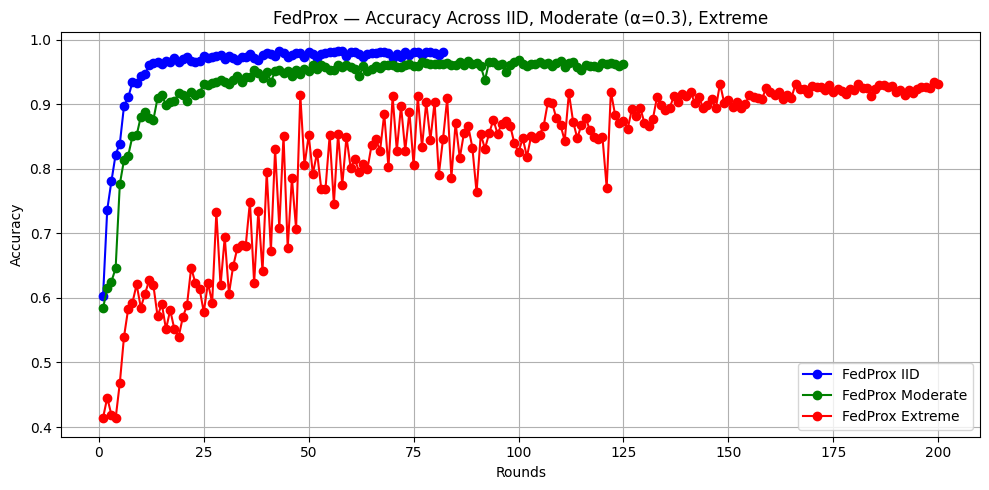

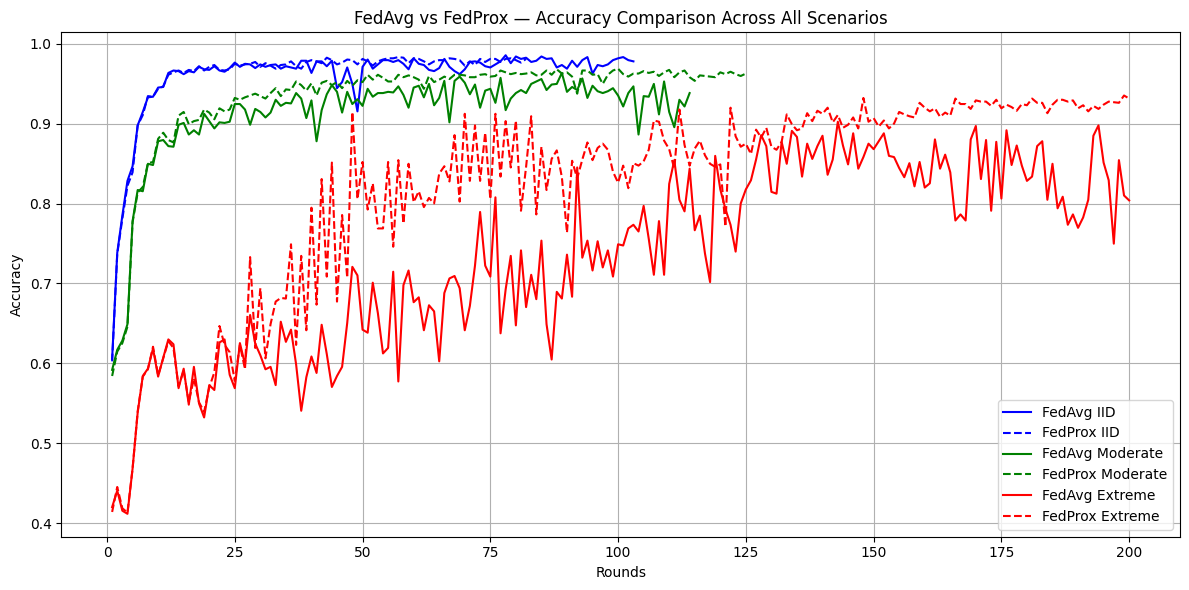

✔ All comparison plots generated successfully!


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CORRECT FILE PATHS (from your directory listing)
# ============================================================

paths_fedavg = {
    "IID":      "metrics_history_fedavg_iid_pretrained.npy",
    "Moderate": "metrics_history_fedavg_moderate_pretrained_alpha3.npy",
    "Extreme":  "metrics_history_fedavg_extreme_pretrained_NEW.npy"
}

paths_fedprox = {
    "IID":      "metrics_history_fedprox_iid_pretrained.npy",
    "Moderate": "metrics_history_fedprox_moderate_pretrained_alpha3.npy",
    "Extreme":  "metrics_history_fedprox_extreme_pretrained.npy"
}


# ============================================================
# HELPER FUNCTION — Load rounds, accuracy, loss
# ============================================================

def load_metrics(path):
    hist = np.load(path, allow_pickle=True).item()
    rounds = hist["round"]
    acc    = [m["acc"] for m in hist["holdout"]]
    loss   = [m["loss"] for m in hist["holdout"]]
    return rounds, acc, loss


# ============================================================
# LOAD FEDAVG METRICS
# ============================================================

fedavg_data = {}
for scenario, path in paths_fedavg.items():
    rounds, acc, loss = load_metrics(path)
    fedavg_data[scenario] = {
        "rounds": rounds,
        "acc": acc,
        "loss": loss
    }


# ============================================================
# LOAD FEDPROX METRICS
# ============================================================

fedprox_data = {}
for scenario, path in paths_fedprox.items():
    rounds, acc, loss = load_metrics(path)
    fedprox_data[scenario] = {
        "rounds": rounds,
        "acc": acc,
        "loss": loss
    }


# ============================================================
# COLOR MAPPING FOR CONSISTENT VISUALS
# ============================================================

colors = {
    "IID": "blue",
    "Moderate": "green",
    "Extreme": "red"
}


# ============================================================
# PLOT 1 — FEDAVG Accuracy Across All Scenarios
# ============================================================

plt.figure(figsize=(10,5))

for scenario, info in fedavg_data.items():
    plt.plot(info["rounds"], info["acc"], marker='o',
             color=colors[scenario], label=f"FedAvg {scenario}")

plt.title("FedAvg — Accuracy Across IID, Moderate (α=0.3), Extreme")
plt.xlabel("Rounds")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# PLOT 2 — FEDPROX Accuracy Across All Scenarios
# ============================================================

plt.figure(figsize=(10,5))

for scenario, info in fedprox_data.items():
    plt.plot(info["rounds"], info["acc"], marker='o',
             color=colors[scenario], label=f"FedProx {scenario}")

plt.title("FedProx — Accuracy Across IID, Moderate (α=0.3), Extreme")
plt.xlabel("Rounds")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# PLOT 3 — FedAvg vs FedProx (Same Scenario Comparisons)
# ============================================================

plt.figure(figsize=(12,6))

for scenario in ["IID", "Moderate", "Extreme"]:
    # FedAvg
    plt.plot(fedavg_data[scenario]["rounds"],
             fedavg_data[scenario]["acc"],
             linestyle='-',
             color=colors[scenario],
             label=f"FedAvg {scenario}")

    # FedProx
    plt.plot(fedprox_data[scenario]["rounds"],
             fedprox_data[scenario]["acc"],
             linestyle='--',
             color=colors[scenario],
             label=f"FedProx {scenario}")

plt.title("FedAvg vs FedProx — Accuracy Comparison Across All Scenarios")
plt.xlabel("Rounds")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


print("✔ All comparison plots generated successfully!")


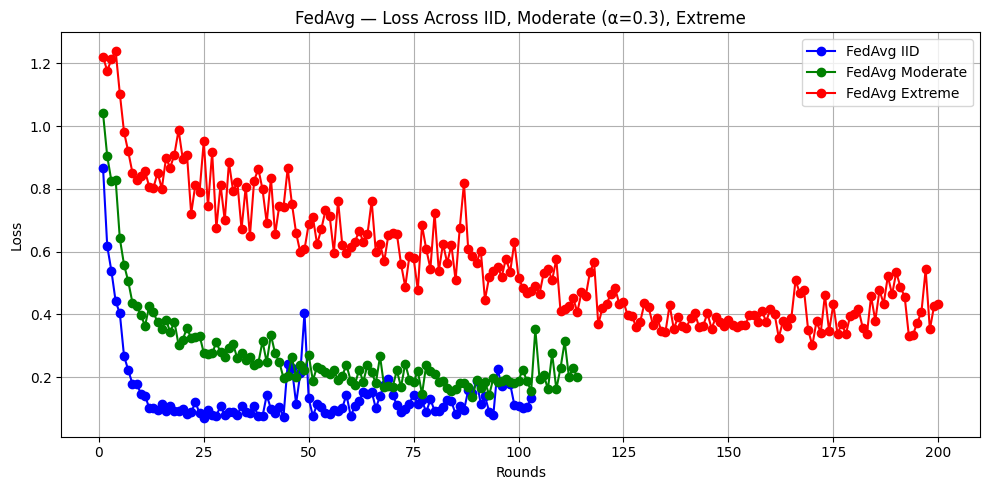

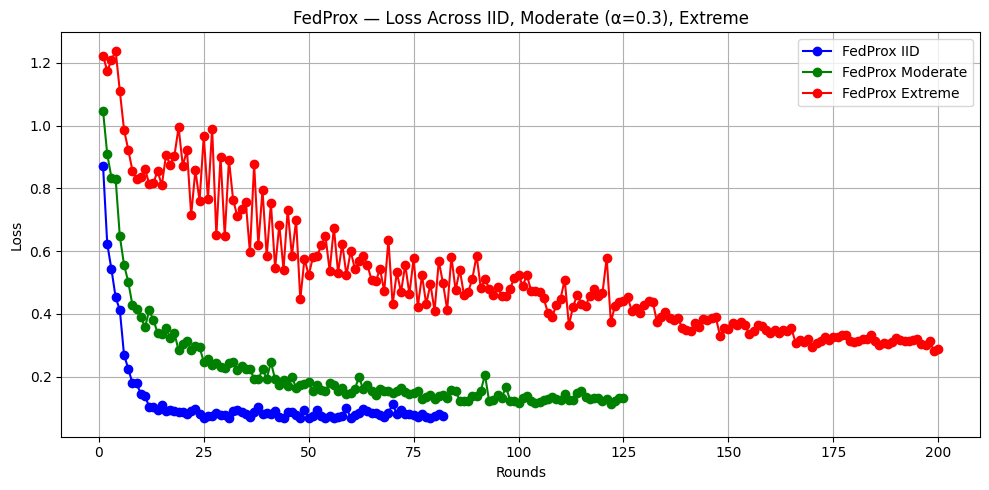

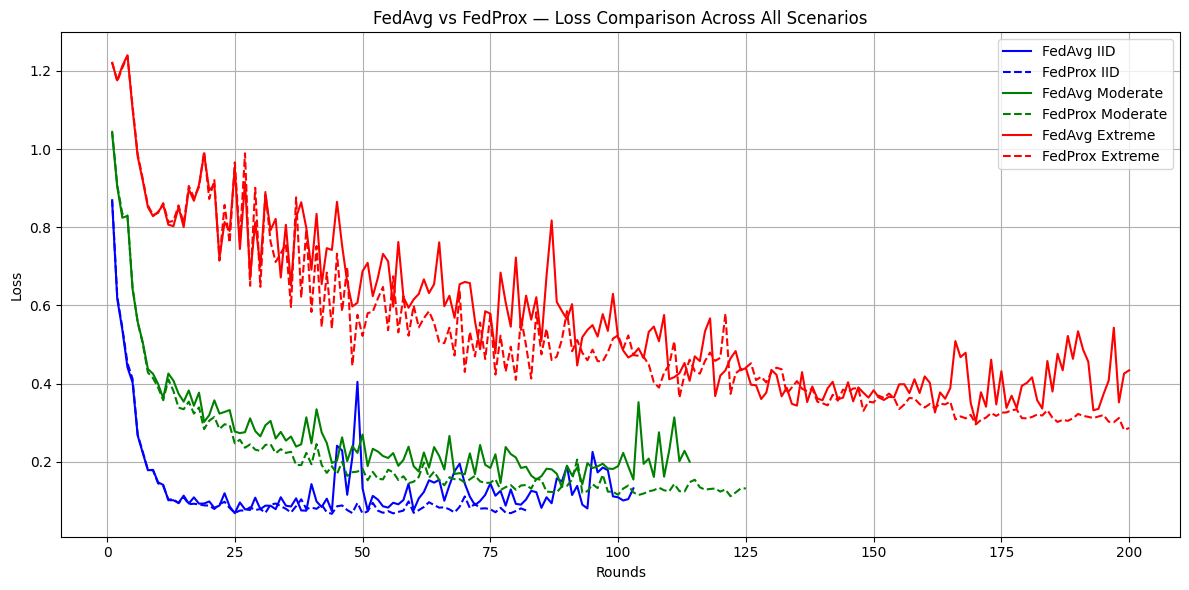

✔ All loss comparison plots generated successfully!


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CORRECT FILE PATHS (from your directory listing)
# ============================================================

paths_fedavg = {
    "IID":      "metrics_history_fedavg_iid_pretrained.npy",
    "Moderate": "metrics_history_fedavg_moderate_pretrained_alpha3.npy",
    "Extreme":  "metrics_history_fedavg_extreme_pretrained_NEW.npy"
}

paths_fedprox = {
    "IID":      "metrics_history_fedprox_iid_pretrained.npy",
    "Moderate": "metrics_history_fedprox_moderate_pretrained_alpha3.npy",
    "Extreme":  "metrics_history_fedprox_extreme_pretrained.npy"
}


# ============================================================
# HELPER FUNCTION — Load rounds, accuracy, loss
# ============================================================

def load_metrics(path):
    hist = np.load(path, allow_pickle=True).item()
    rounds = hist["round"]
    acc    = [m["acc"] for m in hist["holdout"]]
    loss   = [m["loss"] for m in hist["holdout"]]
    return rounds, acc, loss


# ============================================================
# LOAD METRICS FOR FEDAVG
# ============================================================

fedavg_data = {}
for scenario, path in paths_fedavg.items():
    rounds, acc, loss = load_metrics(path)
    fedavg_data[scenario] = {
        "rounds": rounds,
        "acc": acc,
        "loss": loss
    }


# ============================================================
# LOAD METRICS FOR FEDPROX
# ============================================================

fedprox_data = {}
for scenario, path in paths_fedprox.items():
    rounds, acc, loss = load_metrics(path)
    fedprox_data[scenario] = {
        "rounds": rounds,
        "acc": acc,
        "loss": loss
    }


# ============================================================
# COLOR MAPPING
# ============================================================

colors = {
    "IID": "blue",
    "Moderate": "green",
    "Extreme": "red"
}


# ============================================================
# PLOT 1 — FEDAVG Loss Across All Scenarios
# ============================================================

plt.figure(figsize=(10,5))

for scenario, info in fedavg_data.items():
    plt.plot(info["rounds"], info["loss"], marker='o',
             color=colors[scenario], label=f"FedAvg {scenario}")

plt.title("FedAvg — Loss Across IID, Moderate (α=0.3), Extreme")
plt.xlabel("Rounds")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# PLOT 2 — FEDPROX Loss Across All Scenarios
# ============================================================

plt.figure(figsize=(10,5))

for scenario, info in fedprox_data.items():
    plt.plot(info["rounds"], info["loss"], marker='o',
             color=colors[scenario], label=f"FedProx {scenario}")

plt.title("FedProx — Loss Across IID, Moderate (α=0.3), Extreme")
plt.xlabel("Rounds")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# PLOT 3 — FedAvg vs FedProx LOSS Comparison
# ============================================================

plt.figure(figsize=(12,6))

for scenario in ["IID", "Moderate", "Extreme"]:
    
    # FedAvg
    plt.plot(
        fedavg_data[scenario]["rounds"],
        fedavg_data[scenario]["loss"],
        linestyle='-',
        color=colors[scenario],
        label=f"FedAvg {scenario}"
    )

    # FedProx
    plt.plot(
        fedprox_data[scenario]["rounds"],
        fedprox_data[scenario]["loss"],
        linestyle='--',
        color=colors[scenario],
        label=f"FedProx {scenario}"
    )

plt.title("FedAvg vs FedProx — Loss Comparison Across All Scenarios")
plt.xlabel("Rounds")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print("✔ All loss comparison plots generated successfully!")
